In [ ]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset
from time import time
import torch.nn.functional as F # dropout, loss, activation functions, and more
from sklearn.datasets import make_regression

In [ ]:
bias = 20
X_numpy, y_numpy, coef = make_regression(
    n_samples=10000,
    n_features=1,
    n_targets=1,
    noise=50,
    bias=bias,
    coef=True,
    random_state=6
)

In [ ]:
# Creating a PyTorch Dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset

# Define a Dataset
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index].unsqueeze(0)

dataset = RegressionDataset(X_numpy, y_numpy)

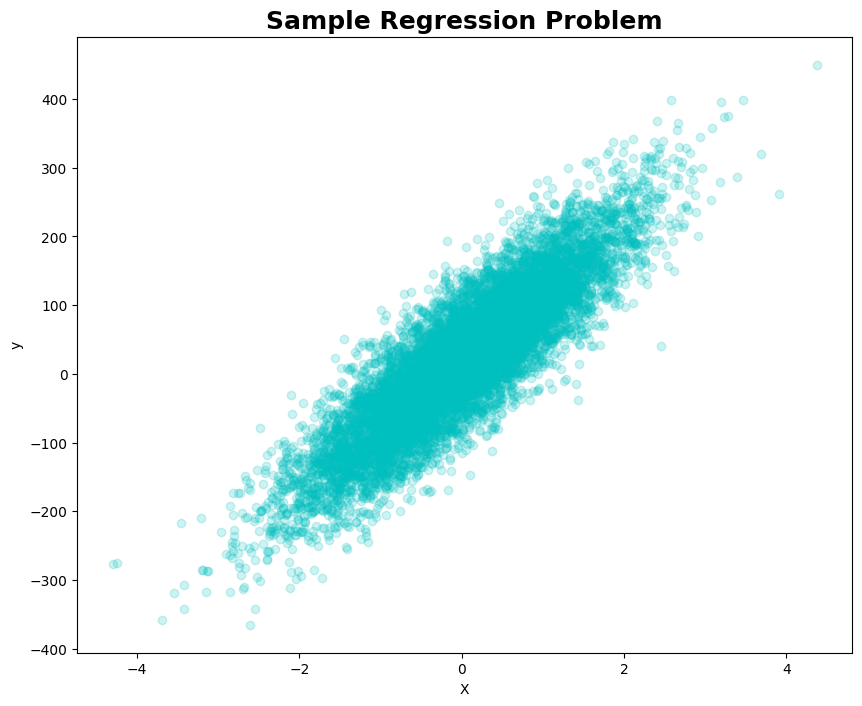

In [ ]:
# Create a Scatter Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_numpy, y_numpy, c='c', marker='o', alpha=0.2)

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Sample Regression Problem', size=18, weight='bold')

# Show the plot
plt.show()

In [ ]:
train_dataset, valid_dataset,test_dataset = random_split(dataset, lengths=[0.6,0.2,0.2])

In [ ]:
# Create DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=True
)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
class SimpleLinearRegression(nn.Module):
    def __init__(self, input_size=1, output_size=1, initial_qhat_raw=0.0):
        super(SimpleLinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)  # Main prediction layer

        # Define qhat as a raw learnable parameter
        self.qhat = nn.Parameter(torch.tensor(1, dtype=torch.float32))

    @property
    def qhat(self):
        # Ensure qhat is always positive using softplus
        return torch.nn.functional.softplus(self.qhat_raw)

    def forward(self, x):
        # Main prediction
        y_pred = self.linear(x)

        # Confidence interval: [y_pred - qhat, y_pred + qhat]
        lower_bound = y_pred - self.qhat
        upper_bound = y_pred + self.qhat

        # Return both the prediction and the confidence interval bounds
        return y_pred, lower_bound, upper_bound

In [ ]:
# Define Linear Regression Class
class Neural_net(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(1,512)
        self.l2 = nn.Linear(512,256)
        self.l3 = nn.Linear(256,128)
        self.l4 = nn.Linear(128,1)

        # Define qhat as a raw learnable parameter
        self.qhat = nn.Parameter(torch.tensor(1.0))  # You can initialize this to any value

    @property
    def qhat(self):
        # Ensure qhat is always positive using softplus
        return torch.nn.functional.softplus(self.qhat_raw)

    def forward(self, x):
      # Main prediction
      x = self.l1(x)

      x = F.relu(x)

      x = self.l2(x)

      x = F.relu(x)

      x = self.l3(x)

      x = F.relu(x)

      y_pred = self.l4(x)

      # Confidence interval: [y_pred - qhat, y_pred + qhat]
      lower_bound = y_pred - self.qhat
      upper_bound = y_pred + self.qhat

      # Return both the prediction and the confidence interval bounds
      return y_pred, lower_bound, upper_bound

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Setting up lists to track losses
model = SimpleLinearRegression()
train_losses = []
val_losses = []
cov = []

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
def fun_conf_scores(y_true, y_pred):
  res = torch.abs(y_true - y_pred)
  return res

def smooth_cal(conf_scores, alpha):
  n = len(conf_scores)
  tau = torch.quantile(conf_scores, alpha*(1+1/n))
  return tau

def smooth_pred(y_true, y_pred, tau, T=1):
  conf_scores = fun_conf_scores(y_true, y_pred)
  C = torch.sigmoid((conf_scores - tau)/T)
  return C

def coverage(y_true, y_pred, qhat, sharpness=10):
    """
    Calculate the coverage in a differentiable way using the sigmoid function.

    Args:
        y_true (torch.Tensor): Ground truth target values.
        y_pred (torch.Tensor): Predicted values.
        qhat (torch.Tensor): The predicted width of the confidence intervals.
        sharpness (float): Controls how sharp the sigmoid function is (larger = more like a step function).

    Returns:
        torch.Tensor: The average coverage (a differentiable approximation).
    """

    # Calculate the lower and upper bounds of the prediction interval
    lower_bound = y_pred - qhat
    upper_bound = y_pred + qhat

    # Use sigmoid to softly check if y_true is within the interval
    inside_lower_bound = torch.sigmoid(sharpness * (y_true - lower_bound))  # y_true >= lower_bound
    inside_upper_bound = torch.sigmoid(sharpness * (upper_bound - y_true))  # y_true <= upper_bound

    # Multiply to get coverage probabilities (values close to 1 mean the target is within the interval)
    coverage = inside_lower_bound * inside_upper_bound

    # Return the average coverage over all data points
    return torch.mean(coverage)


In [ ]:
def conformal_training(model, train_loader, optimizer, epoch, alpha, lambda_1, lambda_2, device):
    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Forward pass: Get the prediction and confidence interval
        outputs, lower_bound, upper_bound = model(inputs)


        # Compute coverage (this function should be differentiable)
        cover = coverage(targets, outputs, model.qhat)

        # Loss function: prediction loss + interval width penalty + coverage penalty
        mse_loss = criterion(outputs, targets)
        interval_width_penalty = lambda_1* 2*torch.abs(model.qhat)
        #interval_width_penalty = torch.mean(-lower_bound + upper_bound)
        coverage_penalty = lambda_2 * (torch.max(torch.tensor(0.0, device=device), (1 - alpha - cover)))

        # Total loss
        loss = mse_loss + interval_width_penalty + coverage_penalty

        # Zero the gradients
        optimizer.zero_grad()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Accumulate train loss
        train_loss += loss.item()
        cov.append(cover.item())

    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}] | Train Loss: {avg_loss:.4f} | qhat: {model.qhat.item():.4f} | cover: {cover} | mes: {mse_loss}')
    return avg_loss


In [ ]:
model.to(device)  # Move the model to the device
num_epochs = 1000
for epoch in range(num_epochs):
    conformal_training(model, train_loader, optimizer, epoch, alpha=0.05, lambda_1=20, lambda_2= 20000, device=device)

Epoch [1] | Train Loss: 27404.4795 | qhat: 18.7793 | cover: 0.17128382623195648 | mes: 8613.7265625
Epoch [2] | Train Loss: 22165.6833 | qhat: 33.2650 | cover: 0.2689349949359894 | mes: 6117.88232421875
Epoch [3] | Train Loss: 16276.4092 | qhat: 48.7703 | cover: 0.4963170886039734 | mes: 4215.595703125
Epoch [4] | Train Loss: 11195.2888 | qhat: 64.3973 | cover: 0.7332114577293396 | mes: 3081.69287109375
Epoch [5] | Train Loss: 8163.4655 | qhat: 72.3693 | cover: 0.8129734396934509 | mes: 3165.139892578125
Epoch [6] | Train Loss: 7463.7647 | qhat: 76.6401 | cover: 0.845755398273468 | mes: 2776.640380859375
Epoch [7] | Train Loss: 7028.3216 | qhat: 79.5176 | cover: 0.9045738577842712 | mes: 2426.232177734375
Epoch [8] | Train Loss: 6847.5544 | qhat: 86.5126 | cover: 0.9218063950538635 | mes: 2473.6708984375
Epoch [9] | Train Loss: 6712.1524 | qhat: 87.5553 | cover: 0.9133197665214539 | mes: 2683.798828125
Epoch [10] | Train Loss: 6726.2065 | qhat: 87.3004 | cover: 0.902164876461029 | mes:

In [ ]:
X_test, y_test = test_dataset[:]
y_pred_test, lower_test, upper_test = model(X_test)
y_pred_big, lower_big, upper_big = model(torch.tensor(X_numpy).float())

x_range = torch.arange(-4,4, step = 0.25).float()
y_pred, lower_bound, upper_bound = model(X_test)

y_pred = y_pred.detach().numpy()
lower_bound = lower_bound.detach().numpy()
upper_bound = upper_bound.detach().numpy()

qhat = np.abs(model.qhat.item())
print(qhat)

98.86945343017578


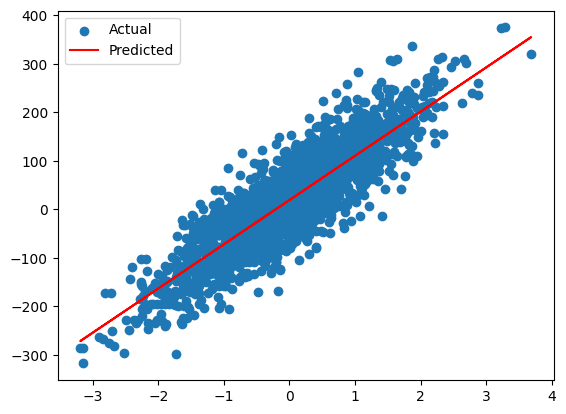

In [ ]:
plt.scatter(X_test, y_test, label = 'Actual')
plt.plot(X_test, y_pred, label = 'Predicted', color = 'red')
plt.legend()
plt.show()

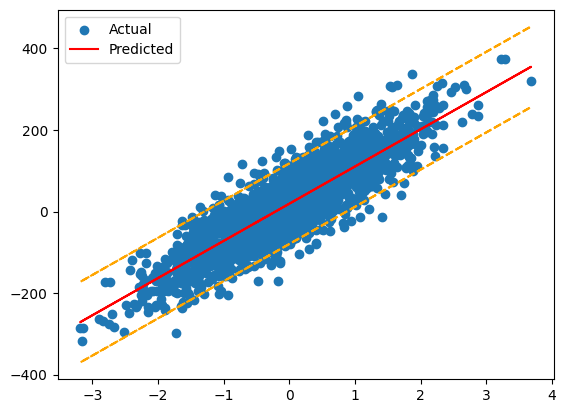

0.9485
0.9475


In [ ]:

pred_set_nn = [(y_pr-qhat,y_pr+qhat) for y_pr in y_pred_test]
pred_set_big = [(y_pr-qhat,y_pr+qhat) for y_pr in y_pred_big]
plt.scatter(X_test.flatten(), y_test.flatten(), label = 'Actual')
plt.plot(X_test, y_pred, label = 'Predicted', color = 'red')
# Extract lower and upper bounds from pred_set
#lower_bound = [t[0].item() for t in pred_set_nn]
#upper_bound = [t[1].item() for t in pred_set_nn]

plt.plot(X_test, lower_bound, color='orange', linestyle='--')
plt.plot(X_test, upper_bound, color='orange', linestyle='--')
plt.legend()
plt.show()

def coverage(y_test, interval):
  n = 0
  for i,item_test in enumerate(y_test.flatten()):
    if (item_test >= interval[i][0] and (item_test <= interval[i][1])):
      n += 1

  perc_correct = n/len(y_test.flatten())

  return perc_correct

cover_test = coverage(y_test, pred_set_nn)
print(cover_test)
cover_big = coverage(y_numpy, pred_set_big)
print(cover_big)


In [ ]:
X_valid, y_valid = valid_dataset[:]
y_pred_valid, lower_valid, upper_valid = model(X_valid)

y_valid = y_valid.flatten()
y_pred_valid = y_pred_valid.flatten()

conf_scores = fun_conf_scores(y_valid, y_pred_valid)
tau = np.quantile(conf_scores.detach().numpy(), 0.95)

pred_set_nn = [(y_pr-tau,y_pr+tau) for y_pr in y_pred_valid]

y_pred_numpy, lower_big, upper_big = model(torch.tensor(X_numpy, dtype = torch.float32))
y_pred_numpy = y_pred_numpy.flatten()
y_pred_numpy = y_pred_numpy.flatten()
pred_set_big = [(y_pr-tau,y_pr+tau) for y_pr in y_pred_numpy]



print(tau)

print(coverage(y_numpy, pred_set_big))

101.81395950317383
0.9556


<ipython-input-42-67a440b5cd85>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_noisy = torch.tensor(y + noise).float().unsqueeze(-1)


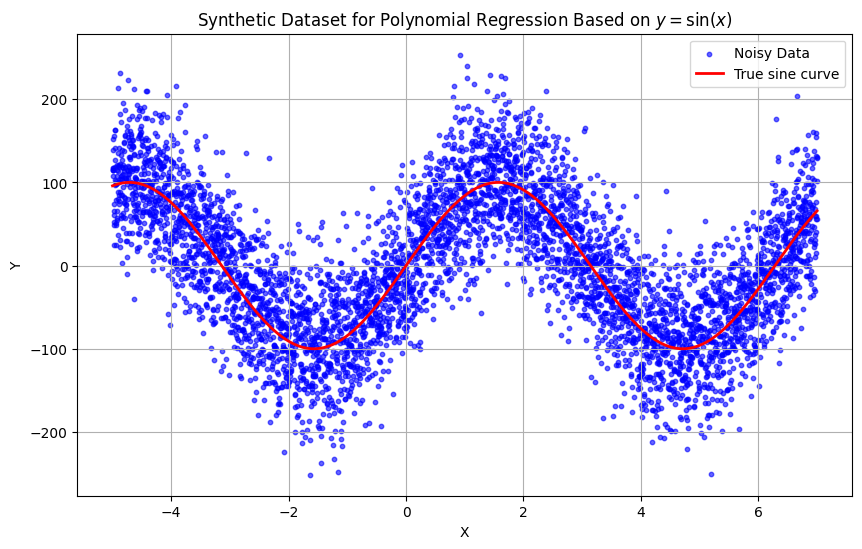

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = torch.linspace(-5, 7, 5000).float().unsqueeze(-1)


# Generate y values based on the sine function
y = 100*np.sin(x).flatten()

# Add some noise to simulate real-world data
noise = 50 * np.random.randn(5000)
y_noisy = torch.tensor(y + noise).float().unsqueeze(-1)

# Plot the noisy data points and the original sine curve
plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, s=10, label="Noisy Data", color='b', alpha=0.6)
plt.plot(x, y, label="True sine curve", color='r', linewidth=2)
plt.title("Synthetic Dataset for Polynomial Regression Based on $y = \sin(x)$")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
dataset2 = TensorDataset(x,y_noisy)


In [ ]:
train_dataset2, valid_dataset2,test_dataset2 = random_split(dataset2, lengths=[0.6,0.2,0.2])

In [ ]:
# Create DataLoaders
train_loader2 = DataLoader(
    dataset=train_dataset2,
    batch_size=128,
    shuffle=True
)

test_loader2 = DataLoader(
    dataset=test_dataset2,
    batch_size=64,
    shuffle=True
)

valid_loader2 = DataLoader(
    dataset=valid_dataset2,
    batch_size=64,
    shuffle=True
)

In [ ]:
# Setting up lists to track losses
model = Neural_net()
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)

model.apply(init_weights)
train_losses = []
val_losses = []

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
model.to(device)  # Move the model to the device
num_epochs = 2000
for epoch in range(num_epochs):
    conformal_training(model, train_loader2, optimizer, epoch, alpha=0.05, lambda_1=10, lambda_2= 20000, device=device)

Epoch [1] | Train Loss: 26770.3421 | qhat: 1.1632 | cover: 0.010125579312443733 | mes: 5097.41455078125
Epoch [2] | Train Loss: 25974.3300 | qhat: 1.3278 | cover: 0.03456282988190651 | mes: 7924.73095703125
Epoch [3] | Train Loss: 25899.5238 | qhat: 1.4628 | cover: 0.050875578075647354 | mes: 4799.09716796875
Epoch [4] | Train Loss: 25940.4950 | qhat: 1.6056 | cover: 0.016392728313803673 | mes: 8300.5859375
Epoch [5] | Train Loss: 25947.7906 | qhat: 1.7389 | cover: 4.984569089541745e-15 | mes: 7450.9443359375
Epoch [6] | Train Loss: 25795.5579 | qhat: 1.8630 | cover: 0.03511933237314224 | mes: 8533.6083984375
Epoch [7] | Train Loss: 25703.3710 | qhat: 1.9841 | cover: 1.2336084410924375e-11 | mes: 5081.27197265625
Epoch [8] | Train Loss: 25676.4756 | qhat: 2.0927 | cover: 0.00026300750323571265 | mes: 5724.26806640625
Epoch [9] | Train Loss: 26026.8058 | qhat: 2.1927 | cover: 7.029385962198376e-10 | mes: 7665.39453125
Epoch [10] | Train Loss: 25866.6353 | qhat: 2.2901 | cover: 0.0178578

KeyboardInterrupt: 

In [ ]:
X_test, y_test = test_dataset2[:]
y_pred_test, lower_test, upper_test = model(X_test)
y_pred_big, lower_big, upper_big = model(torch.tensor(X_numpy).float())

x_range = torch.arange(-5,7, step = 0.25).float()
y_bound, lower_bound, upper_bound = model(x_range.unsqueeze(-1))


y_bound = y_bound.detach().numpy()
lower_bound = lower_bound.detach().numpy()
upper_bound = upper_bound.detach().numpy()

qhat = np.abs(model.qhat.item())
print(qhat)

103.12037658691406


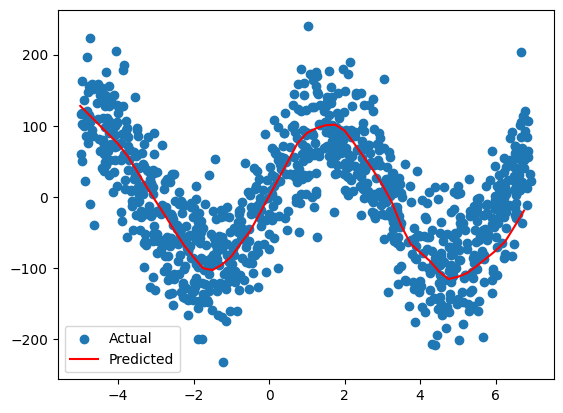

In [ ]:
plt.scatter(X_test, y_test, label = 'Actual')
plt.plot(x_range, y_bound, label = 'Predicted', color = 'red')
plt.legend()
plt.show()

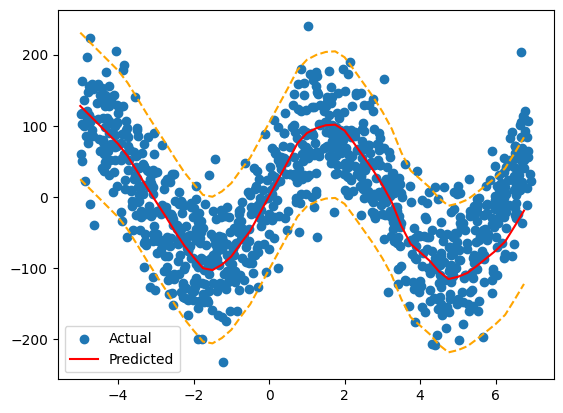

0.941
0.8914


In [ ]:

pred_set_nn = [(y_pr-qhat,y_pr+qhat) for y_pr in y_pred_test]
pred_set_big = [(y_pr-qhat,y_pr+qhat) for y_pr in y_pred_big]
plt.scatter(X_test.flatten(), y_test.flatten(), label = 'Actual')
plt.plot(x_range, y_bound, label = 'Predicted', color = 'red')
# Extract lower and upper bounds from pred_set
#lower_bound = [t[0].item() for t in pred_set_nn]
#upper_bound = [t[1].item() for t in pred_set_nn]

plt.plot(x_range, lower_bound, color='orange', linestyle='--')
plt.plot(x_range, upper_bound, color='orange', linestyle='--')
plt.legend()
plt.show()

def coverage(y_test, interval):
  n = 0
  for i,item_test in enumerate(y_test.flatten()):
    if (item_test >= interval[i][0] and (item_test <= interval[i][1])):
      n += 1

  perc_correct = n/len(y_test.flatten())

  return perc_correct

cover_test = coverage(y_test, pred_set_nn)
print(cover_test)


In [ ]:


conf_scores = fun_conf_scores(y_test, y_pred_test)
tau = np.quantile(conf_scores.detach().numpy(), 0.95)

pred_set_nn = [(y_pr-tau,y_pr+tau) for y_pr in y_pred_test]





print(tau)

print(coverage(y_test, pred_set_nn))

107.90297889709471
0.95
